In [1]:
%pip install imbalanced-learn

#import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import geopandas as gpd
from shapely.geometry import Point
from sklearn.impute import SimpleImputer
import scipy.stats as stats
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from pandas.plotting import parallel_coordinates
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

Note: you may need to restart the kernel to use updated packages.



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [ ]:
# read df_final_merged.geojson file in MergedDatasets
import geopandas as gpd
df_final_merged = gpd.read_file('../../MergedDatasets/df_final_merged.geojson')

In [ ]:
df_final_merged.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 23180 entries, 0 to 23179
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   match_type         23180 non-null  object  
 1   distance_m         23180 non-null  float64 
 2   cell_id            23180 non-null  int32   
 3   month_1            23180 non-null  object  
 4   month_2            23180 non-null  object  
 5   month_3            23180 non-null  object  
 6   month_4            23180 non-null  object  
 7   month_5            23180 non-null  object  
 8   month_6            23180 non-null  object  
 9   month_7            23180 non-null  object  
 10  month_8            23180 non-null  object  
 11  month_9            23180 non-null  object  
 12  month_10           23180 non-null  object  
 13  month_11           23180 non-null  object  
 14  month_12           23180 non-null  object  
 15  x                  23180 non-null  float64 
 

In [ ]:
df_final_merged.head()

,match_type,distance_m,cell_id,month_1,month_2,month_3,month_4,month_5,month_6,month_7,...,area_log,lcc_Bare lands,lcc_Croplands,lcc_Forests,lcc_Grasslands,lcc_Unclassified,lcc_Vegetation,lcc_Water bodies,fire,geometry
0,nearest,5730.516569,0,"[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(20.0), np.float64(33.75), np.float...","[np.float64(23.0), np.float64(36.75), np.float...","[np.float64(27.75), np.float64(42.0), np.float...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.26815, -8.56891 27..."
1,nearest,4333.944079,1,"[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(25.0), np.float6...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(18.0), np.float64(32.0), np.float6...","[np.float64(19.25), np.float64(33.25), np.floa...","[np.float64(22.75), np.float64(36.25), np.floa...","[np.float64(27.0), np.float64(41.75), np.float...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.36815, -8.56891 27..."
2,nearest,3326.267859,2,"[np.float64(8.5), np.float64(22.0), np.float64...","[np.float64(11.0), np.float64(24.75), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.5), np.float64(31.5), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.5), np.float6...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.46815, -8.56891 27..."
3,nearest,3329.154720,3,"[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.75), np.float64(24.0), np.float...","[np.float64(13.0), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.0), np.float6...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.56815, -8.56891 27..."
4,nearest,3332.056800,4,"[np.float64(8.0), np.float64(22.0), np.float64...","[np.float64(10.0), np.float64(24.0), np.float6...","[np.float64(12.5), np.float64(27.0), np.float6...","[np.float64(17.0), np.float64(31.0), np.float6...","[np.float64(19.0), np.float64(33.0), np.float6...","[np.float64(22.0), np.float64(36.0), np.float6...","[np.float64(27.0), np.float64(41.0), np.float6...",...,26.539949,True,False,False,False,False,False,False,0,"MULTIPOLYGON (((-8.56891 27.66815, -8.56891 27..."


### Dropping Columns

In [ ]:
cols_to_drop = ['geometry', 'cell_id', 'match_type', 'distance_m','area_log','x','y']
df_final_merged.drop(columns=cols_to_drop, inplace=True)
df_final_merged.shape

(23180, 44)

# **Preprocessing** 
doesnt involve normalization 

In [6]:
# Expand monthly climate columns with enhanced parsing and imputation
df_climate_expanded = df_final_merged.copy()
climate_cols = ['month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6',
                'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']
import ast
import re

def parse_triplet(val):
    # Already a list/tuple/array
    if isinstance(val, (list, tuple, np.ndarray)):
        if len(val) >= 3:
            try:
                return [float(val[0]), float(val[1]), float(val[2])]
            except:
                return np.nan
        return np.nan
    
    if pd.isna(val):
        return np.nan
    
    if isinstance(val, (float, int, np.number)):
        return np.nan
    
    if isinstance(val, str):
        s = val.strip()
        if not s:
            return np.nan
        
        # Remove common wrappers
        s = s.replace('np.float64', '').replace('array', '')
        s = s.replace('(', ' ').replace(')', ' ')
        
        # Try literal eval first for clean lists
        if s.strip().startswith('[') and s.strip().endswith(']'):
            try:
                out = ast.literal_eval(s.strip())
                if isinstance(out, (list, tuple)) and len(out) >= 3:
                    return [float(out[0]), float(out[1]), float(out[2])]
            except:
                pass
        
        # Extract all numbers using regex
        nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', s)
        if len(nums) >= 3:
            try:
                return [float(nums[0]), float(nums[1]), float(nums[2])]
            except:
                return np.nan
    
    return np.nan

# Store raw values for diagnostics
raw_month_values = {}
for col in climate_cols:
    if col in df_climate_expanded.columns:
        raw_month_values[col] = df_climate_expanded[col].copy()

# Parse triplets
parsed_stats = {}
for col in climate_cols:
    if col in df_climate_expanded.columns:
        df_climate_expanded[col] = df_climate_expanded[col].apply(parse_triplet)
        
        # Diagnostics
        total = len(df_climate_expanded)
        valid = df_climate_expanded[col].apply(lambda x: isinstance(x, list) and len(x) == 3).sum()
        parsed_stats[col] = (valid, total)
        
        # Sample unparsed values
        if valid < total:
            failed_mask = ~df_climate_expanded[col].apply(lambda x: isinstance(x, list) and len(x) == 3)
            samples = raw_month_values[col][failed_mask].dropna().astype(str).head(3).tolist()
            print(f"{col}: {valid}/{total} parsed ({100*valid/total:.1f}%) | Sample unparsed: {samples}")

# Expand into separate columns
for i, col in enumerate(climate_cols, start=1):
    if col in df_climate_expanded.columns:
        df_climate_expanded[f'temp_min_{i}'] = df_climate_expanded[col].apply(
            lambda x: x[0] if isinstance(x, list) and len(x) == 3 else np.nan)
        df_climate_expanded[f'temp_max_{i}'] = df_climate_expanded[col].apply(
            lambda x: x[1] if isinstance(x, list) and len(x) == 3 else np.nan)
        df_climate_expanded[f'precip_{i}'] = df_climate_expanded[col].apply(
            lambda x: x[2] if isinstance(x, list) and len(x) == 3 else np.nan)
        df_climate_expanded.drop(columns=[col], inplace=True)

# Report NaNs before imputation
climate_columns = [c for c in df_climate_expanded.columns 
                   if c.startswith('temp_min_') or c.startswith('temp_max_') or c.startswith('precip_')]
nan_before = df_climate_expanded[climate_columns].isna().sum()
print("\n=== NaNs before imputation ===")
print(nan_before[nan_before > 0])

# Imputation: column-wise mean for each variable type
for prefix in ['temp_min', 'temp_max', 'precip']:
    cols = [f'{prefix}_{i}' for i in range(1, 13) if f'{prefix}_{i}' in df_climate_expanded.columns]
    if cols:
        # Per-column mean imputation
        for col in cols:
            col_mean = df_climate_expanded[col].mean(skipna=True)
            df_climate_expanded[col].fillna(col_mean, inplace=True)
        
        # Overall mean as fallback for rows that are still all NaN
        overall_mean = df_climate_expanded[cols].mean(skipna=True).mean()
        for col in cols:
            df_climate_expanded[col].fillna(overall_mean, inplace=True)

# Report NaNs after imputation
nan_after = df_climate_expanded[climate_columns].isna().sum()
print("\n=== NaNs after imputation ===")
if nan_after.sum() == 0:
    print("All NaNs successfully imputed!")
else:
    print(nan_after[nan_after > 0])

print(f"\n✓ Climate expansion complete: {len(climate_columns)} new columns created")


=== NaNs before imputation ===
Series([], dtype: int64)

=== NaNs after imputation ===
All NaNs successfully imputed!

✓ Climate expansion complete: 36 new columns created


C:\Users\E15\AppData\Local\Temp\ipykernel_16076\2514777204.py:100: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_climate_expanded[col].fillna(col_mean, inplace=True)
C:\Users\E15\AppData\Local\Temp\ipykernel_16076\2514777204.py:105: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [7]:
df_climate_expanded.head()

,x,y,HWSD2_SMU_ID_soil,COARSE_soil,SAND_soil,SILT_soil,CLAY_soil,BULK_soil,REF_BULK_soil,ORG_CARBON_soil,...,precip_9,temp_min_10,temp_max_10,precip_10,temp_min_11,temp_max_11,precip_11,temp_min_12,temp_max_12,precip_12
0,-8.574054,27.262808,1830,12,49,33,18,1.45,1.68,0.697,...,52.099998,18.0,31.0,7.625,14.0,27.0,6.125,8.0,22.00,4.100
1,-8.618508,27.341545,1830,12,49,33,18,1.45,1.68,0.697,...,51.900002,18.0,31.0,7.150,14.0,27.0,6.200,8.0,21.75,4.100
2,-8.618494,27.423112,1844,12,49,33,18,1.45,1.68,0.697,...,52.450001,18.0,31.0,8.125,13.5,27.0,6.450,8.0,21.25,5.300
3,-8.618481,27.495017,1844,12,49,33,18,1.45,1.68,0.697,...,52.750000,18.0,31.0,8.100,13.0,27.0,7.325,8.0,21.00,5.625
4,-8.618457,27.631494,1844,12,49,33,18,1.45,1.68,0.697,...,53.025002,18.0,31.0,8.100,13.0,26.0,7.300,8.0,21.00,6.500


# **SPLIT**

In [8]:
# train test split test validation
from sklearn.model_selection import train_test_split
X = df_climate_expanded.drop(columns=['fire'])
y = df_climate_expanded['fire']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# **Sampling**

=== Original Class Distribution ===
Train set: {0: 15285, 1: 941}
Train ratio: {0: 0.9420066559842228, 1: 0.057993344015777146}

=== Applying SMOTE ===
SMOTE train set: {0: 15285, 1: 15285}
SMOTE ratio: {0: 0.5, 1: 0.5}

=== Applying Tomek Links ===
SMOTE train set: {0: 15285, 1: 15285}
SMOTE ratio: {0: 0.5, 1: 0.5}

=== Applying Tomek Links ===
Tomek train set: {0: 14975, 1: 941}
Tomek ratio: {0: 0.940877104800201, 1: 0.05912289519979894}

=== Applying SMOTE + Tomek Links ===
Tomek train set: {0: 14975, 1: 941}
Tomek ratio: {0: 0.940877104800201, 1: 0.05912289519979894}

=== Applying SMOTE + Tomek Links ===
SMOTE+Tomek train set: {0: 15252, 1: 15252}
SMOTE+Tomek ratio: {0: 0.5, 1: 0.5}

=== Resampling Summary ===
SMOTE+Tomek train set: {0: 15252, 1: 15252}
SMOTE+Tomek ratio: {0: 0.5, 1: 0.5}

=== Resampling Summary ===


,Method,Total_Samples,Class_0,Class_1,Balance_Ratio
0,Original,16226,15285,941,0.061564
1,SMOTE,30570,15285,15285,1.000000
2,Tomek,15916,14975,941,0.062838
3,SMOTE+Tomek,30504,15252,15252,1.000000


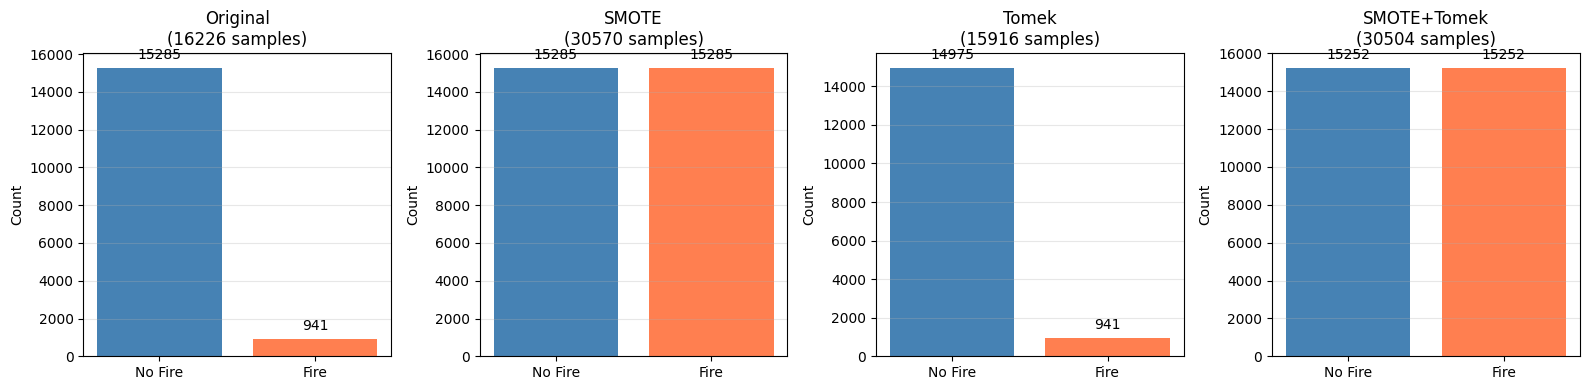


✓ All resampling techniques applied successfully!


In [ ]:
# Apply different resampling techniques: SMOTE, Tomek Links, and SMOTE+Tomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

# Check original class distribution
print("=== Original Class Distribution ===")
print(f"Train set: {y_train.value_counts().to_dict()}")
print(f"Train ratio: {y_train.value_counts(normalize=True).to_dict()}")

# 1) SMOTE (Synthetic Minority Over-sampling Technique)
print("\n=== Applying SMOTE ===")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(train_set_normalized, y_train)
print(f"SMOTE train set: {y_train_smote.value_counts().to_dict()}")
print(f"SMOTE ratio: {y_train_smote.value_counts(normalize=True).to_dict()}")

# 2) Tomek Links (Under-sampling by removing Tomek pairs)
print("\n=== Applying Tomek Links ===")
tomek = TomekLinks(sampling_strategy='auto')
X_train_tomek, y_train_tomek = tomek.fit_resample(train_set_normalized, y_train)
print(f"Tomek train set: {y_train_tomek.value_counts().to_dict()}")
print(f"Tomek ratio: {y_train_tomek.value_counts(normalize=True).to_dict()}")

# 3) SMOTE + Tomek Links (Combined approach)
print("\n=== Applying SMOTE + Tomek Links ===")
smote_tomek = SMOTETomek(random_state=42, smote=SMOTE(random_state=42, k_neighbors=5))
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(train_set_normalized, y_train)
print(f"SMOTE+Tomek train set: {y_train_smote_tomek.value_counts().to_dict()}")
print(f"SMOTE+Tomek ratio: {y_train_smote_tomek.value_counts(normalize=True).to_dict()}")

# Summary comparison
print("\n=== Resampling Summary ===")
summary_df = pd.DataFrame({
    'Method': ['Original', 'SMOTE', 'Tomek', 'SMOTE+Tomek'],
    'Total_Samples': [
        len(y_train),
        len(y_train_smote),
        len(y_train_tomek),
        len(y_train_smote_tomek)
    ],
    'Class_0': [
        (y_train == 0).sum(),
        (y_train_smote == 0).sum(),
        (y_train_tomek == 0).sum(),
        (y_train_smote_tomek == 0).sum()
    ],
    'Class_1': [
        (y_train == 1).sum(),
        (y_train_smote == 1).sum(),
        (y_train_tomek == 1).sum(),
        (y_train_smote_tomek == 1).sum()
    ]
})
summary_df['Balance_Ratio'] = summary_df['Class_1'] / summary_df['Class_0']
display(summary_df)

# Visualize class distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
datasets = [
    (y_train, 'Original'),
    (y_train_smote, 'SMOTE'),
    (y_train_tomek, 'Tomek'),
    (y_train_smote_tomek, 'SMOTE+Tomek')
]

for ax, (y_data, title) in zip(axes, datasets):
    counts = y_data.value_counts().sort_index()
    ax.bar(['No Fire', 'Fire'], counts.values, color=['steelblue', 'coral'])
    ax.set_title(f'{title}\n({len(y_data)} samples)')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values)*0.02, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../../Rapport_TP/images/MergedPreprocess/resampling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ All resampling techniques applied successfully!")

### **Save Resampled Datasets**

In [ ]:
# Save all resampled versions for later use
import pickle

# Create dictionary of all datasets
resampled_data = {
    'original': {'X_train': train_set_normalized, 'y_train': y_train},
    'smote': {'X_train': X_train_smote, 'y_train': y_train_smote},
    'tomek': {'X_train': X_train_tomek, 'y_train': y_train_tomek},
    'smote_tomek': {'X_train': X_train_smote_tomek, 'y_train': y_train_smote_tomek},
    'test': {'X_test': X_test, 'y_test': y_test},
    'val': {'X_val': X_val, 'y_val': y_val}
}

In [ ]:
# Save as pickle
with open('../../MergedDatasets/resampled_data.pkl', 'wb') as f:
    pickle.dump(resampled_data, f)

print("✓ Resampled datasets saved to: ../../MergedDatasets/resampled_data.pkl")

# Also save final normalized dataframe
train_set_normalized.to_csv('../../MergedDatasets/train_set_normalized.csv', index=False)
print("✓ Final normalized dataset saved to: ../../MergedDatasets/train_set_normalized.csv")

✓ Resampled datasets saved to: ../../MergedDatasets/resampled_data.pkl
✓ Final normalized dataset saved to: ../../MergedDatasets/train_set_normalized.csv
✓ Final normalized dataset saved to: ../../MergedDatasets/train_set_normalized.csv
